In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu

plt.rcParams['figure.figsize'] = (8, 4)
sns.set_style('whitegrid')

In [2]:
REPO_URL = 'https://github.com/LuisBetancourt11/Proyecto_Ciencia_Datos.git'
REPO_DIR = 'Proyecto_Ciencia_Datos'

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL}
else:
    print("Repositorio ya clonado; actualizando...")
    !cd {REPO_DIR} && git pull

Cloning into 'Proyecto_Ciencia_Datos'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 101 (delta 38), reused 13 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 1.25 MiB | 6.97 MiB/s, done.
Resolving deltas: 100% (38/38), done.


In [12]:
processed_dir = REPO_DIR + '/data/processed/'
df = pd.read_csv(processed_dir + 'matriculas_limpias.csv',
                 parse_dates=['fecha_de_matricula'])

# Subconjunto con etiqueta válida (excluye los estados ambiguos -> NaN)
d = df.dropna(subset=['desercion']).copy()
d['desercion'] = d['desercion'].astype(int)

BASE = d['desercion'].mean()   # tasa global de deserción (línea de referencia)
print("Filas totales:", df.shape, "| Etiquetadas:", d.shape)
print(f"Tasa global de deserción (base rate): {BASE:.1%}")
df.head()

Filas totales: (13397, 23) | Etiquetadas: (13036, 23)
Tasa global de deserción (base rate): 35.2%


,genero,municipio_de_nacimiento,pais,municipio_direccion,barrio_direccion,estrato,estado_civil,eps,grupo_sisben,zona,...,estado,fecha_de_matricula,jornada,programa,periodo,nivel,edad,anio_matricula,mes_matricula,desercion
0,Femenino,Medellín,Colombia,Envigado,Las Flores,3.0,Soltero(a),EPS Sura,NaN,Urbana,...,Graduado,2018-02-05 10:00:00,MEDIA TÉCNICA,MEDIA TÉCNICA TECNICO LABORAL AUXILIAR ADMINIS...,2018-2,SEMESTRE 2,20.0,2018.0,2.0,0.0
1,Femenino,Envigado,Colombia,Envigado,San José,2.0,Soltero(a),EPS Sura,NaN,Urbana,...,Graduado,2016-01-19 10:00:00,NOCHE,10T-TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO...,2016-2,SEMESTRE 2,29.0,2016.0,1.0,0.0
2,Masculino,Bogotá,Colombia,La Mesa,NaN,3.0,Soltero(a),NaN,NaN,Rural,...,Cancelado,2021-02-08 10:00:00,NOCHE,09T-TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,2021-2,SEMESTRE 1,19.0,2021.0,2.0,1.0
3,Masculino,Envigado,Colombia,Envigado,San José,2.0,Soltero(a),SISBEN,B3,Urbana,...,Graduado,2020-01-17 10:00:00,DIURNA,01T-TÉCNICO LABORAL AUXILIAR DE TALENTO HUMANO,2021-1,SEMESTRE 2,21.0,2020.0,1.0,0.0
4,Masculino,Medellín,Colombia,Envigado,El Salado,2.0,Soltero(a),Nueva Promotora de Salud - Nueva EPS,N0,Urbana,...,Inactivo,2020-01-27 10:00:00,NOCHE,27T-TÉCNICO LABORAL EN MERCADEO Y VENTAS (Estu...,2020-1,SEMESTRE 1,20.0,2020.0,1.0,1.0


In [4]:
d.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
genero,13036,2,Masculino,6921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
municipio_de_nacimiento,11958,396,Medellín,4421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pais,12988,2,Colombia,12987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
municipio_direccion,12986,27,Envigado,10765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
barrio_direccion,11762,313,La Mina,1027,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estrato,11866.0,NaN,NaN,NaN,2.572055,0.0,2.0,3.0,3.0,6.0,0.731962
estado_civil,11643,7,Soltero(a),9509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
eps,10106,72,EPS Sura,4850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
grupo_sisben,3015,57,A1,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zona,11808,3,Urbana,10583,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Función reutilizable de análisis bivariado
Una sola función para todas las variables categóricas: muestra la **composición**
(desertó / no desertó dentro de cada grupo), marca la **tasa global**

In [18]:
def analizar_categorica(col, min_n=30):
    """Compara desertores y NO desertores en cada grupo + prueba de chi-cuadrado."""
    sub = d[[col, 'desercion']].dropna()
    vc = sub[col].value_counts()
    sub = sub[sub[col].isin(vc[vc >= min_n].index)]   # ignorar categorías muy pequeñas

    # Proporción de desertores y NO desertores DENTRO de cada grupo
    prop = pd.crosstab(sub[col], sub['desercion'], normalize='index')
    prop.columns = ['No desertó (0)', 'Desertó (1)']
    prop = prop.sort_values('Desertó (1)')

    # --- Gráfica: dos barras por grupo (no desertó vs desertó) ---
    prop.plot(kind='barh', color=['#4C72B0', '#C44E52'])
    plt.axvline(BASE, color='black', ls='--',
                label=f'Deserción promedio ({BASE:.0%})')
    plt.xlabel('Proporción del grupo'); plt.xlim(0, 1)
    plt.title(f'Deserción vs no deserción por {col}')
    plt.legend(loc='lower right', fontsize=8); plt.tight_layout(); plt.show()

    # --- Prueba de chi-cuadrado: ¿la diferencia es real o casualidad? ---
    p = chi2_contingency(pd.crosstab(sub[col], sub['desercion']))[1]
    brecha = prop['Desertó (1)'].max() - prop['Desertó (1)'].min()

    # Resumen numérico: % que desertó y que no, más el tamaño de cada grupo
    resumen = (prop * 100).round(1)
    resumen['n'] = sub.groupby(col).size()
    print(resumen)
    print(f"\nDiferencia entre el grupo que más y el que menos deserta: {brecha:.0%}")
    print(f"p-valor (chi-cuadrado): {p:.4f}  ->  " +
          ("la diferencia es REAL (significativa)" if p < 0.05
           else "podría ser casualidad (no significativa)"))

    return {'variable': col, 'p_value': p, 'brecha': brecha,
            'significativa': p < 0.05}

resultados = []

## Pregunta 1 — ¿La deserción difiere entre géneros?

In [19]:
# Tabla: conteo de cada clase (incluye los 'Sin estado' que quedaron como NaN)
conteo = df['desercion'].value_counts(dropna=False)
print(conteo)
print()
print("Proporción (sobre los etiquetados):")
print(df['desercion'].value_counts(normalize=True).round(3))

desercion
0.0    8451
1.0    4585
NaN     361
Name: count, dtype: int64

Proporción (sobre los etiquetados):
desercion
0.0    0.648
1.0    0.352
Name: proportion, dtype: float64


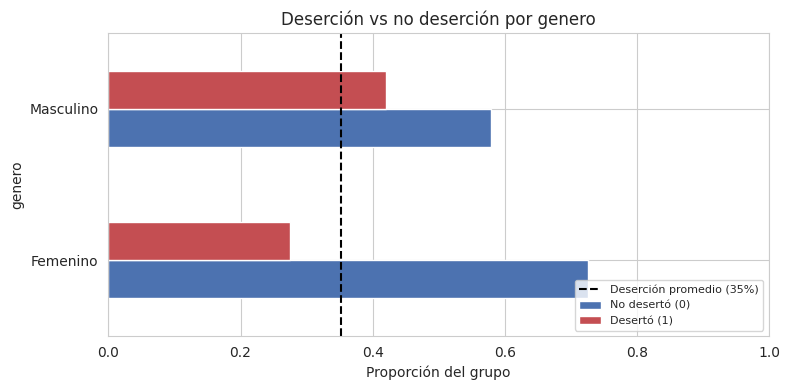

           No desertó (0)  Desertó (1)     n
genero                                      
Femenino             72.6         27.4  6115
Masculino            58.0         42.0  6921

Diferencia entre el grupo que más y el que menos deserta: 15%
p-valor (chi-cuadrado): 0.0000  ->  la diferencia es REAL (significativa)


In [21]:
res = analizar_categorica('genero')
resultados.append(res)

# **Conclusión:**
Los hombres desertan más que las mujeres (42.0% vs 27.4%, ~15 puntos de diferencia), una diferencia significativa que se mantiene por encima y por debajo del promedio general (35%).

#**Pregunta 2:** ¿La jornada se asocia con la deserción?

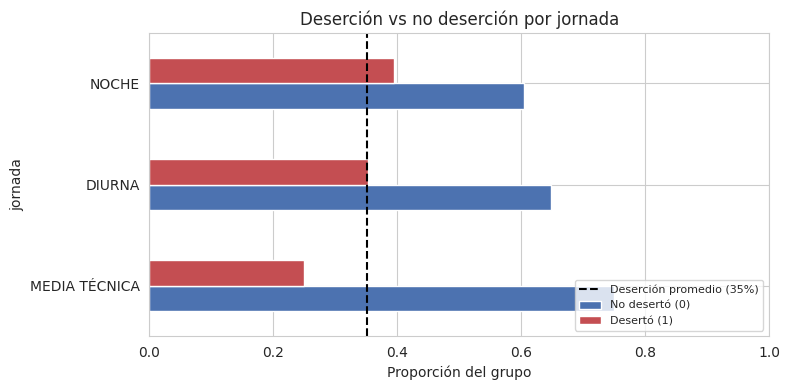

               No desertó (0)  Desertó (1)     n
jornada                                         
MEDIA TÉCNICA            75.0         25.0  2636
DIURNA                   64.8         35.2  4192
NOCHE                    60.5         39.5  6202

Diferencia entre el grupo que más y el que menos deserta: 15%
p-valor (chi-cuadrado): 0.0000  ->  la diferencia es REAL (significativa)


In [22]:
res = analizar_categorica('jornada')
resultados.append(res)

# **Conclusión**
La jornada Noche presenta la mayor deserción (39.5%), seguida de Diurna (35.2%) y Media Técnica, que es la más baja (25.0%), con ~15 puntos de diferencia entre los extremos. Es una diferencia significativa: Noche queda por encima del promedio general (35%) y Media Técnica claramente por debajo.

#**Pregunta 3: ¿El nivel cursado se asocia con la deserción?**

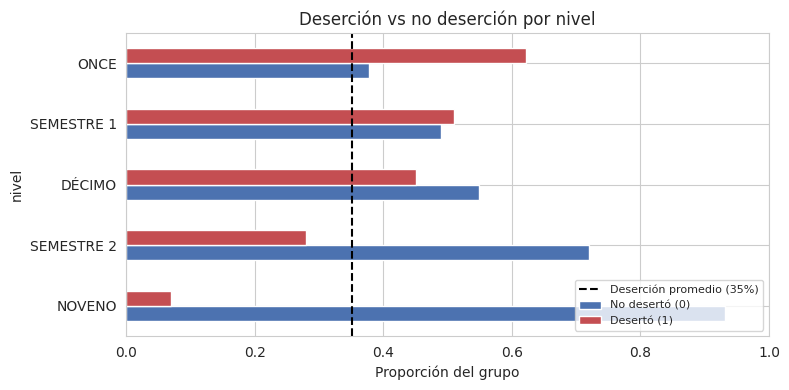

            No desertó (0)  Desertó (1)     n
nivel                                        
NOVENO                93.1          6.9  1529
SEMESTRE 2            72.0         28.0  6164
DÉCIMO                54.9         45.1   517
SEMESTRE 1            49.0         51.0  4326
ONCE                  37.8         62.2   492

Diferencia entre el grupo que más y el que menos deserta: 55%
p-valor (chi-cuadrado): 0.0000  ->  la diferencia es REAL (significativa)


In [23]:
res = analizar_categorica('nivel')
resultados.append(res)

# **Conclusión**
El nivel es la variable que más separa hasta ahora (~55 puntos entre extremos). Once concentra la mayor deserción (62.2%) y Noveno la menor (6.9%), con Semestre 1 (51.0%), Décimo (45.1%) y Semestre 2 (28.0%) en el medio. La diferencia es marcada y significativa.

#**Pregunta 4: ¿El estrato socioeconómico se asocia con la deserción?**


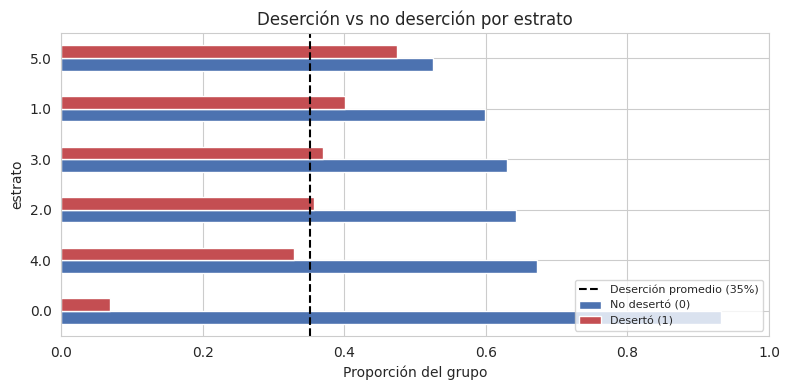

         No desertó (0)  Desertó (1)     n
estrato                                   
0.0                93.2          6.8    44
4.0                67.2         32.8   646
2.0                64.3         35.7  5181
3.0                63.0         37.0  5452
1.0                59.8         40.2   381
5.0                52.6         47.4   135

Diferencia entre el grupo que más y el que menos deserta: 41%
p-valor (chi-cuadrado): 0.0000  ->  la diferencia es REAL (significativa)


In [27]:
res = analizar_categorica('estrato')
resultados.append(res)

# **Conclusión**
Considerando los estratos válidos (1 a 5), la relación con la deserción no es ordenada: no es que a mayor o menor estrato siempre haya más deserción. El estrato 5 presenta la mayor tasa (47.4%) y el estrato 4 la menor (32.8%), con los estratos 1, 2 y 3 en torno al promedio general (35-40%).

# **Pregunta 5: ¿Difiere la deserción entre zona urbana y rural?**

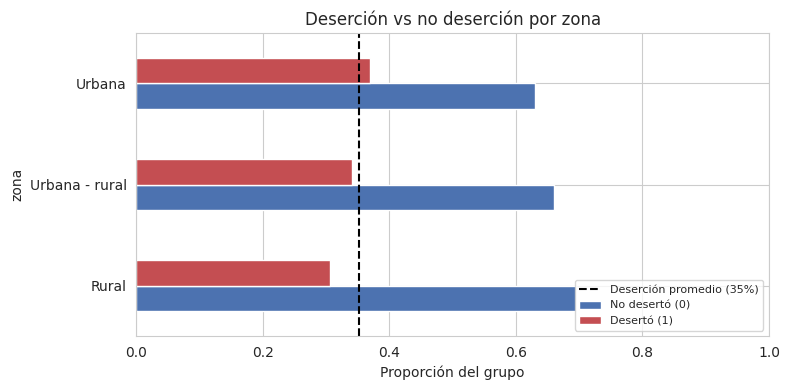

                No desertó (0)  Desertó (1)      n
zona                                              
Rural                     69.5         30.5    799
Urbana - rural            66.0         34.0    426
Urbana                    63.0         37.0  10583

Diferencia entre el grupo que más y el que menos deserta: 6%
p-valor (chi-cuadrado): 0.0008  ->  la diferencia es REAL (significativa)


In [28]:
res = analizar_categorica('zona')
resultados.append(res)

# **Conclusión**
Las tres zonas desertan en niveles muy parecidos: Urbana 37.0%, Urbana-rural 34.0% y Rural 30.5%, apenas ~6 puntos entre extremos, todas cerca del promedio general (35%).

#**Pregunta 6: ¿El estado civil se asocia con la deserción?**

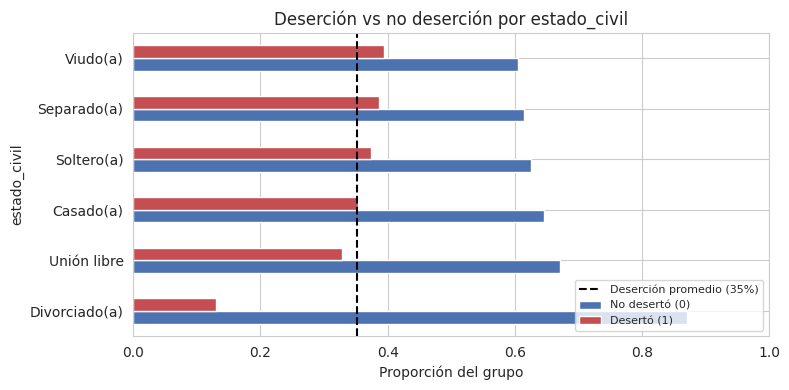

               No desertó (0)  Desertó (1)     n
estado_civil                                    
Divorciado(a)            87.0         13.0    54
Unión libre              67.1         32.9   924
Casado(a)                64.7         35.3   911
Soltero(a)               62.6         37.4  9509
Separado(a)              61.4         38.6   202
Viudo(a)                 60.5         39.5    38

Diferencia entre el grupo que más y el que menos deserta: 27%
p-valor (chi-cuadrado): 0.0005  ->  la diferencia es REAL (significativa)


In [29]:
res = analizar_categorica('estado_civil')
resultados.append(res)

# **Conclusión**
Los solteros, que son la gran mayoría (9.509 casos), desertan 37.4%, por encima del promedio general (35%), mientras que casados (35.3%) y en unión libre (32.9%) desertan algo menos. Los grupos con tasas más extremas —Divorciado(a) 13.0% y Viudo(a) 39.5%— tienen muy pocos registros (54 y 38), por lo que no son confiables y no se interpretan.

#**Pregunta 7: ¿La ocupación se asocia con la deserción?**

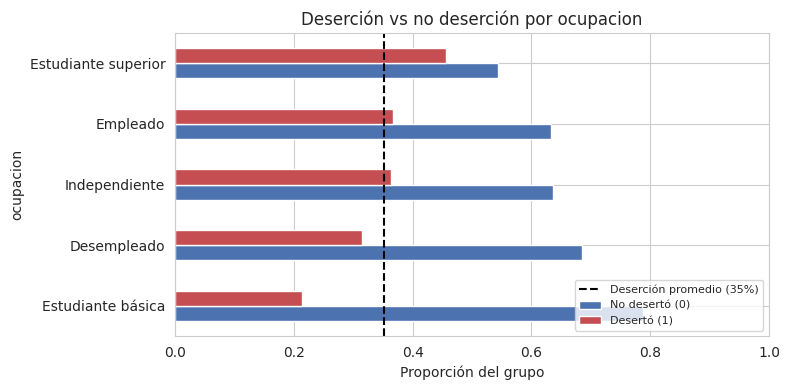

                     No desertó (0)  Desertó (1)     n
ocupacion                                             
Estudiante básica              78.7         21.3  2287
Desempleado                    68.5         31.5  1672
Independiente                  63.6         36.4   969
Empleado                       63.3         36.7  2666
Estudiante superior            54.4         45.6  3590

Diferencia entre el grupo que más y el que menos deserta: 24%
p-valor (chi-cuadrado): 0.0000  ->  la diferencia es REAL (significativa)


In [30]:
res = analizar_categorica('ocupacion')
resultados.append(res)

# **Conclusión**
La ocupación marca una diferencia clara (~24 puntos entre extremos). Los estudiantes de educación superior desertan más (45.6%, por encima del promedio del 35%), mientras que los estudiantes de básica son los que menos desertan (21.3%). Quienes trabajan o están desempleados se ubican en el medio (32-37%). Todos los grupos tienen tamaños amplios, lo que da solidez al resultado.

#**Pregunta 8: ¿El medio de transporte se asocia con la deserción?**


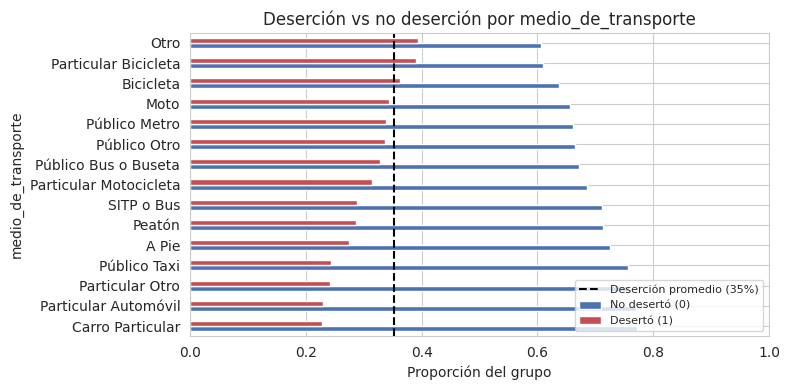

                        No desertó (0)  Desertó (1)     n
medio_de_transporte                                      
Carro Particular                  77.2         22.8   123
Particular Automóvil              77.0         23.0   252
Particular Otro                   75.8         24.2    33
Público Taxi                      75.7         24.3    70
A Pie                             72.6         27.4  2362
Peatón                            71.4         28.6   625
SITP o Bus                        71.2         28.8    59
Particular Motocicleta            68.5         31.5   413
Público Bus o Buseta              67.2         32.8  4336
Público Otro                      66.4         33.6   131
Público Metro                     66.1         33.9   242
Moto                              65.7         34.3   796
Bicicleta                         63.8         36.2   185
Particular Bicicleta              61.0         39.0    77
Otro                              60.6         39.4    94

Diferencia en

In [31]:
res = analizar_categorica('medio_de_transporte')
resultados.append(res)

# **Conclusión**
La brecha entre extremos es de ~17 puntos, pero gran parte la marcan categorías diminutas (poco confiables). En los grupos con muchos casos, quienes usan transporte particular (Carro 22.8%, Automóvil 23.0%) desertan menos que quienes se mueven a pie (27.4%) o en transporte público (Bus/Buseta 32.8%), todos cerca del promedio (35%). El patrón sugiere una posible relación con el nivel socioeconómico más que con el transporte en sí, por lo que es de interpretación dudosa.

# **Pregunta 9: ¿La edad se asocia con la deserción?**


Edad media | no desertó: 28.3 | desertó: 29.1
Mann-Whitney U: p = 3.68e-27 -> SIGNIFICATIVA


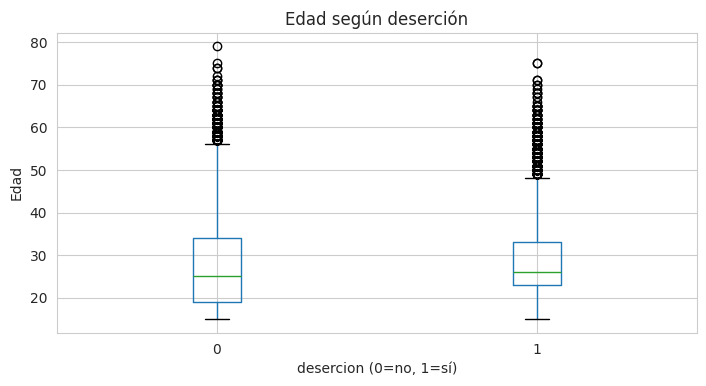

In [33]:
dd = d[(d['edad'] >= 15) & (d['edad'] <= 80)]   # filtrar edades imposibles
g0 = dd.loc[dd.desercion == 0, 'edad']
g1 = dd.loc[dd.desercion == 1, 'edad']

u, p = mannwhitneyu(g0, g1)
print(f"Edad media | no desertó: {g0.mean():.1f} | desertó: {g1.mean():.1f}")
print(f"Mann-Whitney U: p = {p:.2e} -> {'SIGNIFICATIVA' if p < 0.05 else 'no significativa'}")

dd.boxplot(column='edad', by='desercion')
plt.title('Edad según deserción'); plt.suptitle('')
plt.xlabel('desercion (0=no, 1=sí)'); plt.ylabel('Edad'); plt.show()

resultados.append({'variable': 'edad', 'p_value': p,
                   'brecha': np.nan, 'significativa': p < 0.05})

# **Conclusión**
La edad de quienes desertan (media 29.1 años) y de quienes no (28.3 años) es casi idéntica: menos de un año de diferencia, con distribuciones muy superpacapadas. Aunque la diferencia resulta significativa por el gran tamaño de la muestra, su magnitud es tan pequeña que carece de relevancia práctica: la edad, por sí sola, no distingue a los desertores.

# **ANALISIS MULTIVARIADO CON CRUCES DE VARIABLES**

# 1. Deserción según género **y** jornada **texto en negrita**

In [34]:
tabla = (pd.DataFrame(resultados)
         .sort_values('brecha', ascending=False, na_position='last')
         .reset_index(drop=True))
tabla['p_value'] = tabla['p_value'].map(lambda x: f'{x:.2e}')
tabla['brecha'] = (tabla['brecha'] * 100).round(1)   # en puntos porcentuales
print("Ranking de variables (por brecha entre grupos):")
tabla

Ranking de variables (por brecha entre grupos):


,variable,p_value,brecha,significativa
0,nivel,2.28e-287,55.3,True
1,estrato,6.89e-06,40.6,True
2,estrato,6.89e-06,40.6,True
3,estrato,6.89e-06,40.6,True
4,estado_civil,5.19e-04,26.5,True
5,ocupacion,9.04e-80,24.3,True
6,medio_de_transporte,7.73e-06,16.6,True
7,genero,9.11e-68,14.6,True
8,jornada,5.71e-38,14.5,True
9,zona,7.53e-04,6.4,True


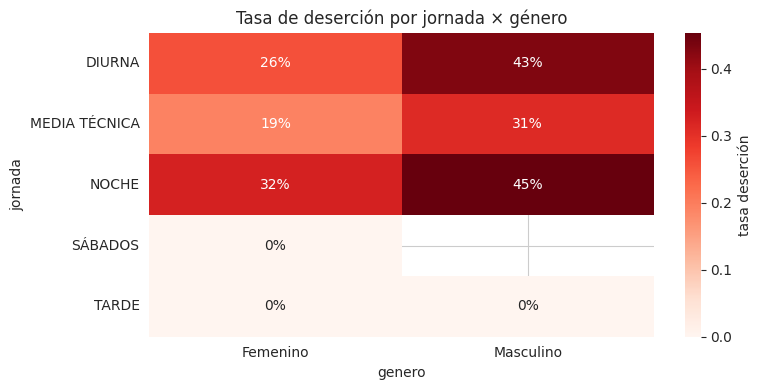

genero,Femenino,Masculino
jornada,,
DIURNA,0.258,0.430
MEDIA TÉCNICA,0.193,0.312
NOCHE,0.325,0.454
SÁBADOS,0.000,NaN
TARDE,0.000,0.000


In [35]:
piv = d.pivot_table(index='jornada', columns='genero',
                    values='desercion', aggfunc='mean')
sns.heatmap(piv, annot=True, fmt='.0%', cmap='Reds', cbar_kws={'label': 'tasa deserción'})
plt.title('Tasa de deserción por jornada × género'); plt.tight_layout(); plt.show()
piv.round(3)

# **Conclusión**
El cruce confirma que ambos efectos se suman, no se cancelan: en las tres jornadas con datos suficientes (Diurna, Media Técnica y Noche), los hombres desertan más que las mujeres de forma consistente. La combinación de mayor riesgo es hombre en jornada Noche (45%), y la de menor riesgo mujer en Media Técnica (19%) —una diferencia de 26 puntos según la celda del cruce.

# **2. Deserción según nivel **y** rango de edad**

/tmp/ipykernel_6213/150501948.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv2 = d2.pivot_table(index='nivel', columns='rango_edad',


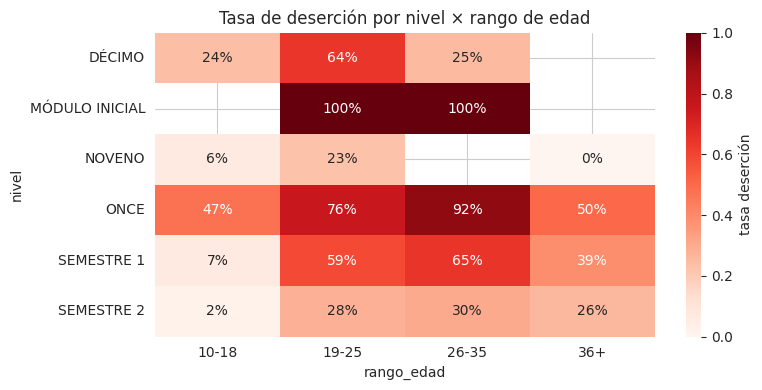

rango_edad,10-18,19-25,26-35,36+
nivel,,,,
DÉCIMO,0.242,0.642,0.250,NaN
MÓDULO INICIAL,NaN,1.000,1.000,NaN
NOVENO,0.064,0.227,NaN,0.000
ONCE,0.473,0.755,0.917,0.500
SEMESTRE 1,0.069,0.588,0.650,0.392
SEMESTRE 2,0.020,0.283,0.301,0.259


In [36]:
d2 = d[(d['edad'] >= 10) & (d['edad'] <= 80)].copy()
d2['rango_edad'] = pd.cut(d2['edad'], bins=[10, 18, 25, 35, 80],
                          labels=['10-18', '19-25', '26-35', '36+'])

piv2 = d2.pivot_table(index='nivel', columns='rango_edad',
                      values='desercion', aggfunc='mean')
sns.heatmap(piv2, annot=True, fmt='.0%', cmap='Reds', cbar_kws={'label': 'tasa deserción'})
plt.title('Tasa de deserción por nivel × rango de edad'); plt.tight_layout(); plt.show()
piv2.round(3)

# **Conclusión**
Dentro de un mismo nivel, entre más edad tiene el estudiante, más tiende a desertar (al menos hasta los 35 años). Por ejemplo, en Semestre 1 la deserción pasa del 7% en los más jóvenes (10-18) al 65% en los de 26-35; y en Once sube del 47% al 92%. Esto nos dice que el estudiante con mayor riesgo no es solo el de cierto nivel, sino el que además tiene más edad. Es interesante porque antes habíamos visto que la edad por sí sola casi no influía, pero al combinarla con el nivel sí aporta información. Por eso pensamos que el modelo debería tener en cuenta estas dos variables juntas. Aclaramos que las casillas con 100% o vacías las dejamos por fuera porque tienen muy pocos datos.